# B2B Sales Pipeline Analysis: Win Rates, Sales Cycle and Rep Performance

**Author:** Murilo Toledo · [Portfolio](https://murilotoledo44-hub.github.io) · [LinkedIn](https://www.linkedin.com/in/murilo-toledoremote)

**Dataset:** CRM + Sales + Opportunities — a B2B company's CRM with accounts, products, sales teams and ~8,800 opportunities (Oct 2016 – Dec 2017).

## Business context
A Revenue Operations team needs a clear read on pipeline health before planning next year's targets. This notebook answers five questions a VP of Sales would ask:

1. **Pipeline health** — How many deals are open, won and lost, and what is our win rate?
2. **Product mix** — Which products win most often, generate the most revenue and hold their price?
3. **Sales cycle** — How long do deals take to close, and does it differ by product?
4. **Trend** — How did won revenue and win rate move month by month?
5. **Team performance** — Which reps, managers and regions over- or under-perform?

The notebook ends with data-quality findings and recommendations for the sales leadership team.

## 1. Setup and data loading

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5.5), "figure.dpi": 110, "axes.titlesize": 13,
                     "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GREY = "#2346D8", "#B8C0CC"
STAGE_COLORS = {"Prospecting": "#B8C0CC", "Engaging": "#7C95FF", "Won": "#2346D8", "Lost": "#DD8452"}

CHART_DIR = "charts"          # charts are saved here for the GitHub README
os.makedirs(CHART_DIR, exist_ok=True)
def save(fig, name):
    fig.savefig(os.path.join(CHART_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")

usd = mticker.FuncFormatter(lambda x, p: f"${x/1e6:.1f}M" if abs(x) >= 1e6 else f"${x/1e3:.0f}K" if abs(x) >= 1e3 else f"${x:,.0f}")

# Find the CSV files wherever Kaggle mounted the dataset
def find(name):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True) or glob.glob(f"**/{name}", recursive=True)
    if not hits:
        raise FileNotFoundError(f"{name} not found — add the dataset via 'Add Input' in the Kaggle sidebar.")
    return hits[0]

accounts  = pd.read_csv(find("accounts.csv"))
products  = pd.read_csv(find("products.csv"))
teams     = pd.read_csv(find("sales_teams.csv"))
pipeline  = pd.read_csv(find("sales_pipeline.csv"), parse_dates=["engage_date", "close_date"])

for name, df in {"accounts": accounts, "products": products, "sales_teams": teams, "sales_pipeline": pipeline}.items():
    print(f"{name:<15} {df.shape[0]:>6,} rows × {df.shape[1]} columns")

accounts            85 rows × 7 columns
products             7 rows × 3 columns
sales_teams         35 rows × 3 columns
sales_pipeline   8,800 rows × 8 columns


## 2. Data quality check
Before any analysis, a RevOps analyst checks whether the CRM can be trusted. Below I look for missing values, inconsistent labels and records that don't match across tables.

In [2]:
print("Missing values in sales_pipeline:\n")
missing = pipeline.isna().sum().to_frame("missing")
missing["% of rows"] = (missing["missing"] / len(pipeline) * 100).round(1)
print(missing[missing["missing"] > 0])

print("\nMissing values by deal stage:")
display(pipeline.groupby("deal_stage")[["account", "engage_date", "close_date", "close_value"]]
        .apply(lambda g: g.isna().sum()))

Missing values in sales_pipeline:

             missing  % of rows
account         1425      16.20
engage_date      500       5.70
close_date      2089      23.70
close_value     2089      23.70

Missing values by deal stage:


,account,engage_date,close_date,close_value
deal_stage,,,,
Engaging,1088,0,1589,1589
Lost,0,0,0,0
Prospecting,337,500,500,500
Won,0,0,0,0


In [3]:
issues = {}

# Product names in the pipeline that don't exist in the product catalog
unmatched_products = sorted(set(pipeline["product"]) - set(products["product"]))
issues["Products not in catalog"] = unmatched_products

# Sector labels (look for typos)
issues["Sector labels"] = sorted(accounts["sector"].dropna().unique())

# Reps in the pipeline without a team assignment
issues["Reps without team"] = sorted(set(pipeline["sales_agent"]) - set(teams["sales_agent"]))

# Duplicate opportunity IDs
issues["Duplicate opportunity IDs"] = int(pipeline["opportunity_id"].duplicated().sum())

for k, v in issues.items():
    print(f"- {k}: {v}")

- Products not in catalog: ['GTXPro']
- Sector labels: ['employment', 'entertainment', 'finance', 'marketing', 'medical', 'retail', 'services', 'software', 'technolgy', 'telecommunications']
- Reps without team: []
- Duplicate opportunity IDs: 0


**Fixes applied:**
- Product names are normalized so the pipeline matches the catalog (e.g. `GTXPro` → `GTX Pro`).
- Sector typos are corrected (e.g. `technolgy` → `technology`).
- Missing `account` / `engage_date` on *Prospecting* deals and missing `close_date` / `close_value` on open deals are **expected** (those fields are filled later in the sales process), so they are kept, not dropped.

In [4]:
def normalize(s):
    return s.str.replace(r"\s+", "", regex=True).str.lower()

catalog = dict(zip(normalize(products["product"]), products["product"]))
pipeline["product"] = normalize(pipeline["product"]).map(catalog).fillna(pipeline["product"])
accounts["sector"] = accounts["sector"].replace({"technolgy": "technology"})

print("Products still unmatched:", sorted(set(pipeline["product"]) - set(products["product"])) or "none")

Products still unmatched: none


## 3. Building the master table

In [5]:
df = (pipeline
      .merge(teams, on="sales_agent", how="left")
      .merge(products, on="product", how="left")
      .merge(accounts[["account", "sector", "revenue", "employees", "office_location"]], on="account", how="left"))

df["is_closed"] = df["deal_stage"].isin(["Won", "Lost"])
df["is_won"] = df["deal_stage"].eq("Won")
df["cycle_days"] = (df["close_date"] - df["engage_date"]).dt.days
df["close_month"] = df["close_date"].dt.to_period("M").dt.to_timestamp()
df["price_realization"] = np.where(df["is_won"], df["close_value"] / df["sales_price"], np.nan)

assert len(df) == len(pipeline), "Join changed the row count — check keys"
df.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,manager,regional_office,...,sales_price,sector,revenue,employees,office_location,is_closed,is_won,cycle_days,close_month,price_realization
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,"1,054.00",Dustin Brinkmann,Central,...,1096,retail,718.62,"2,448.00",United States,True,True,132.00,2017-03-01,0.96
1,Z063OYW0,Darcel Schlecht,GTX Pro,Isdom,Won,2016-10-25,2017-03-11,"4,514.00",Melvin Marxen,Central,...,4821,medical,"3,178.24","4,540.00",United States,True,True,137.00,2017-03-01,0.94
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.00,Melvin Marxen,Central,...,55,retail,718.62,"2,448.00",United States,True,True,133.00,2017-03-01,0.91
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.00,Dustin Brinkmann,Central,...,550,software,"2,714.90","2,641.00",United States,True,True,135.00,2017-03-01,1.07
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.00,Summer Sewald,West,...,550,services,792.46,"1,299.00",United States,True,True,128.00,2017-03-01,0.94


## 4. Headline KPIs

In [6]:
closed = df[df["is_closed"]]
won = df[df["is_won"]]

kpi = {
    "Total opportunities": len(df),
    "Open (Prospecting + Engaging)": int((~df["is_closed"]).sum()),
    "Won": len(won),
    "Lost": int((df["deal_stage"] == "Lost").sum()),
    "Win rate (won / closed)": won.shape[0] / closed.shape[0],
    "Won revenue": won["close_value"].sum(),
    "Average won deal size": won["close_value"].mean(),
    "Median sales cycle (days)": closed["cycle_days"].median(),
}
fmt = {"Win rate (won / closed)": "{:.1%}", "Won revenue": "${:,.0f}", "Average won deal size": "${:,.0f}",
       "Median sales cycle (days)": "{:.0f}"}
for k, v in kpi.items():
    print(f"{k:<32} {fmt.get(k, '{:,}').format(v)}")

Total opportunities              8,800
Open (Prospecting + Engaging)    2,089
Won                              4,238
Lost                             2,473
Win rate (won / closed)          63.2%
Won revenue                      $10,005,534
Average won deal size            $2,361
Median sales cycle (days)        45


## 5. Pipeline health: where are the deals?

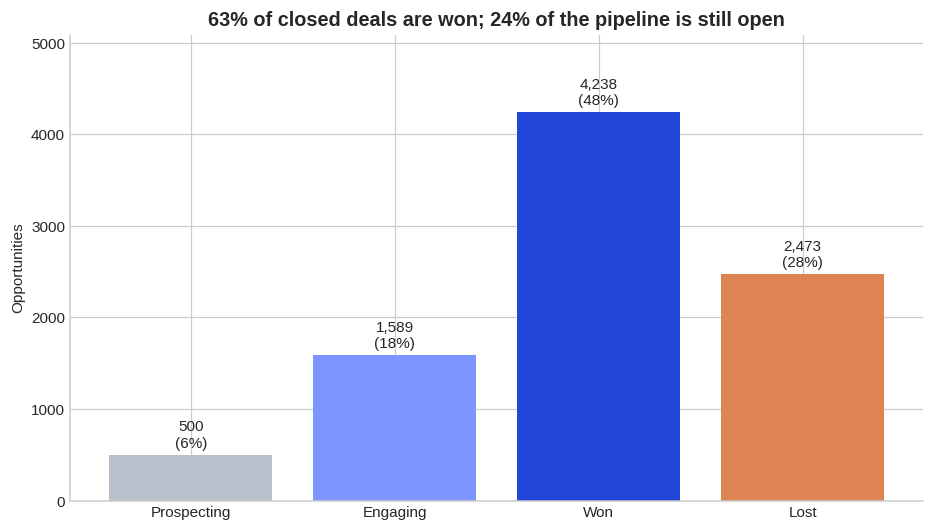

In [7]:
order = ["Prospecting", "Engaging", "Won", "Lost"]
stage_counts = df["deal_stage"].value_counts().reindex(order)

fig, ax = plt.subplots()
bars = ax.bar(order, stage_counts.values, color=[STAGE_COLORS[s] for s in order])
ax.bar_label(bars, labels=[f"{v:,}\n({v/len(df):.0%})" for v in stage_counts.values], padding=3)
open_share = (~df["is_closed"]).mean()
ax.set_title(f"{kpi['Win rate (won / closed)']:.0%} of closed deals are won; {open_share:.0%} of the pipeline is still open")
ax.set_ylabel("Opportunities")
ax.set_ylim(0, stage_counts.max() * 1.2)
save(fig, "01_pipeline_by_stage"); plt.show()

## 6. Product mix: win rate, revenue and pricing

In [8]:
prod = (df.groupby("product")
          .agg(opportunities=("opportunity_id", "count"),
               closed=("is_closed", "sum"),
               won=("is_won", "sum"),
               won_revenue=("close_value", "sum"),
               list_price=("sales_price", "first"),
               avg_price_realization=("price_realization", "mean"))
          .assign(win_rate=lambda t: t["won"] / t["closed"])
          .sort_values("won_revenue", ascending=False))
display(prod.style.format({"won_revenue": "${:,.0f}", "list_price": "${:,.0f}",
                           "avg_price_realization": "{:.1%}", "win_rate": "{:.1%}"}))

,opportunities,closed,won,won_revenue,list_price,avg_price_realization,win_rate
product,,,,,,,
GTX Pro,1480,1147,729,"$3,510,578","$4,821",99.9%,63.6%
GTX Plus Pro,968,745,479,"$2,629,651","$5,482",100.1%,64.3%
MG Advanced,1412,1084,654,"$2,216,387","$3,393",99.9%,60.3%
GTX Plus Basic,1383,1051,653,"$705,275","$1,096",98.5%,62.1%
GTX Basic,1866,1436,915,"$499,263",$550,99.2%,63.7%
GTK 500,40,25,15,"$400,612","$26,768",99.8%,60.0%
MG Special,1651,1223,793,"$43,768",$55,100.4%,64.8%


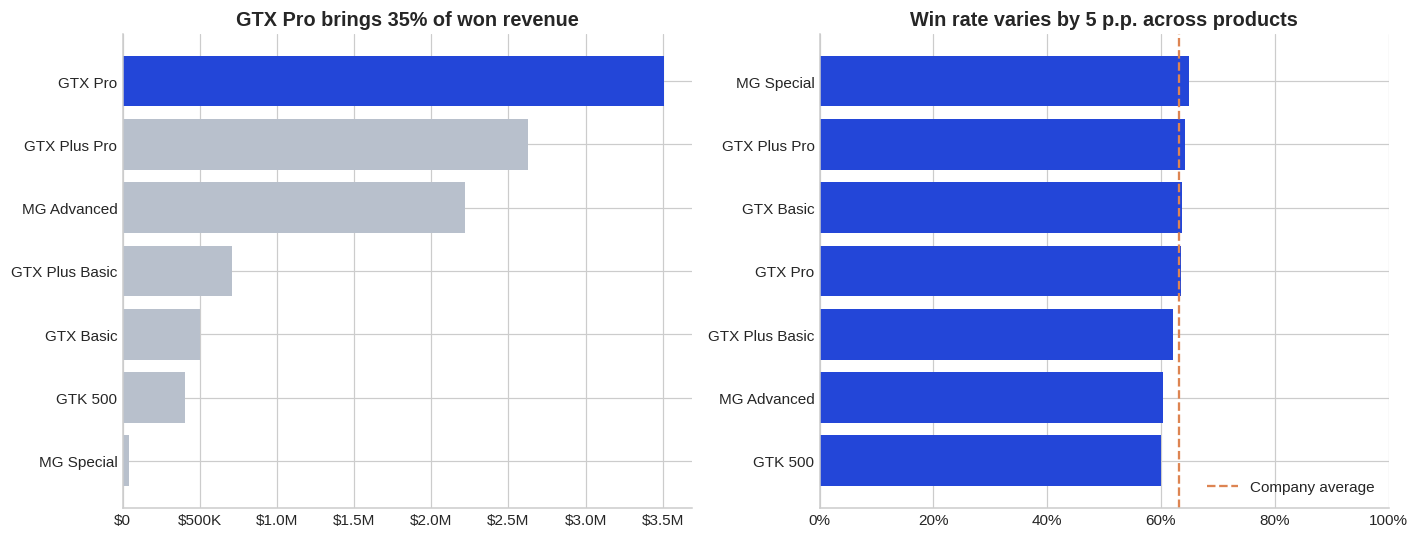

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p = prod.sort_values("won_revenue")
top = p.index[-1]
axes[0].barh(p.index, p["won_revenue"], color=[ACCENT if i == top else GREY for i in p.index])
axes[0].xaxis.set_major_formatter(usd)
share = p.loc[top, "won_revenue"] / p["won_revenue"].sum()
axes[0].set_title(f"{top} brings {share:.0%} of won revenue")

w = prod.sort_values("win_rate")
axes[1].barh(w.index, w["win_rate"], color=ACCENT)
axes[1].axvline(kpi["Win rate (won / closed)"], color="#DD8452", ls="--", label="Company average")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_xlim(0, 1); axes[1].legend(loc="lower right")
spread = w["win_rate"].max() - w["win_rate"].min()
axes[1].set_title(f"Win rate varies by {spread*100:.0f} p.p. across products")

plt.tight_layout(); save(fig, "02_products"); plt.show()

## 7. Sales cycle: how long do deals take?

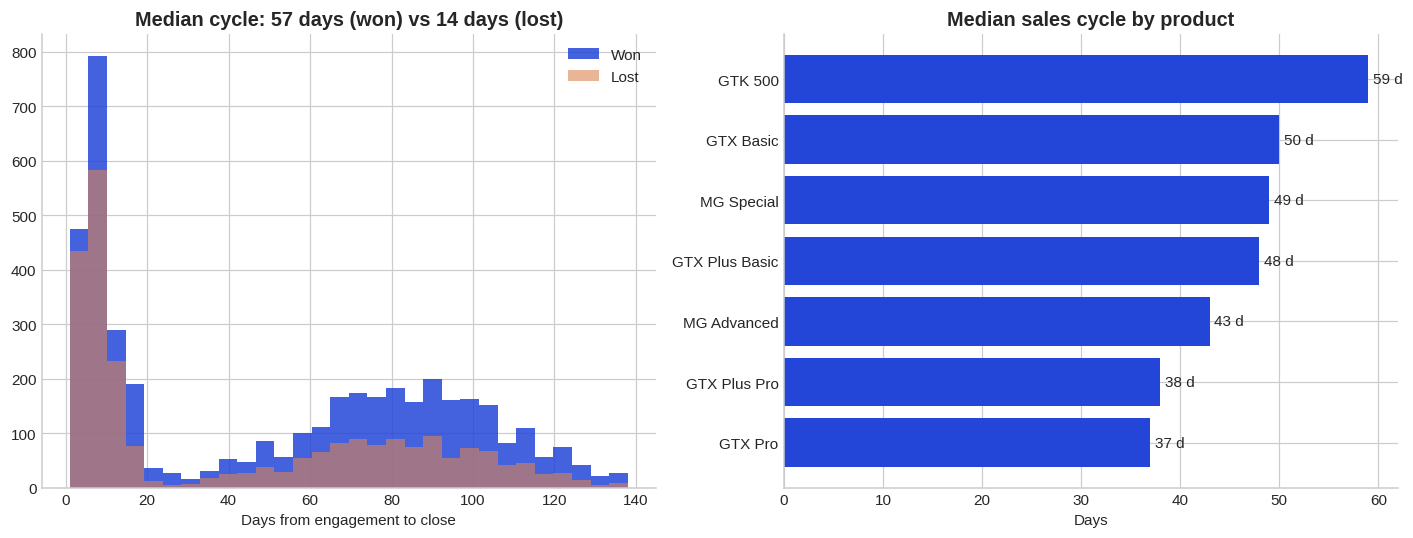

In [10]:
c = closed.dropna(subset=["cycle_days"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(c.loc[c["is_won"], "cycle_days"], bins=30, alpha=.85, color=ACCENT, label="Won")
axes[0].hist(c.loc[~c["is_won"], "cycle_days"], bins=30, alpha=.6, color="#DD8452", label="Lost")
med_won, med_lost = c.loc[c["is_won"], "cycle_days"].median(), c.loc[~c["is_won"], "cycle_days"].median()
axes[0].set_title(f"Median cycle: {med_won:.0f} days (won) vs {med_lost:.0f} days (lost)")
axes[0].set_xlabel("Days from engagement to close"); axes[0].legend()

by_prod = c.groupby("product")["cycle_days"].median().sort_values()
axes[1].barh(by_prod.index, by_prod.values, color=ACCENT)
axes[1].bar_label(axes[1].containers[0], fmt="%.0f d", padding=3)
axes[1].set_title("Median sales cycle by product")
axes[1].set_xlabel("Days")

plt.tight_layout(); save(fig, "03_sales_cycle"); plt.show()

## 8. Monthly trend: revenue and win rate

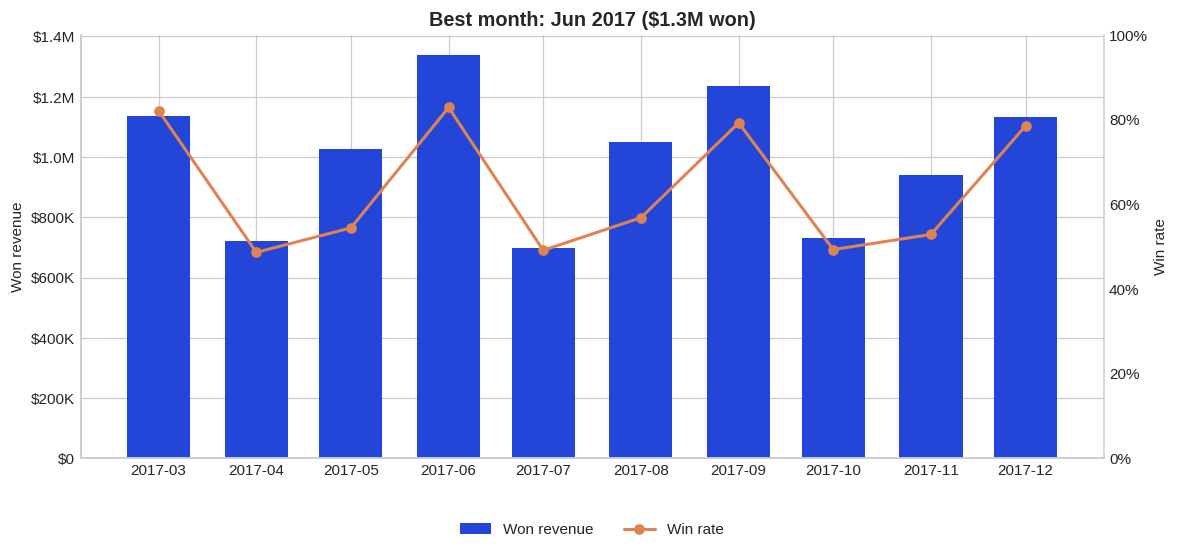

In [11]:
monthly = (closed.groupby("close_month")
                 .agg(won_revenue=("close_value", "sum"), won=("is_won", "sum"), closed=("is_won", "size"))
                 .assign(win_rate=lambda t: t["won"] / t["closed"]))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly.index, monthly["won_revenue"], width=20, color=ACCENT, label="Won revenue")
ax.yaxis.set_major_formatter(usd); ax.set_ylabel("Won revenue")
ax2 = ax.twinx()
ax2.plot(monthly.index, monthly["win_rate"], color="#DD8452", marker="o", lw=2, label="Win rate")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1)); ax2.set_ylim(0, 1); ax2.set_ylabel("Win rate")
ax2.grid(False); ax2.spines["right"].set_visible(True)
best = monthly["won_revenue"].idxmax()
ax.set_title(f"Best month: {best:%b %Y} ({usd(monthly.loc[best, 'won_revenue'])} won)")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
save(fig, "04_monthly_trend"); plt.show()

> Revenue bars and win-rate line use separate axes. Read them as two views of the same months, not as a correlation.
> Also check whether revenue concentrates at quarter-end (Mar, Jun, Sep, Dec) — a common sign of end-of-quarter pushes and discounting.

## 9. Team performance: reps, managers and regions

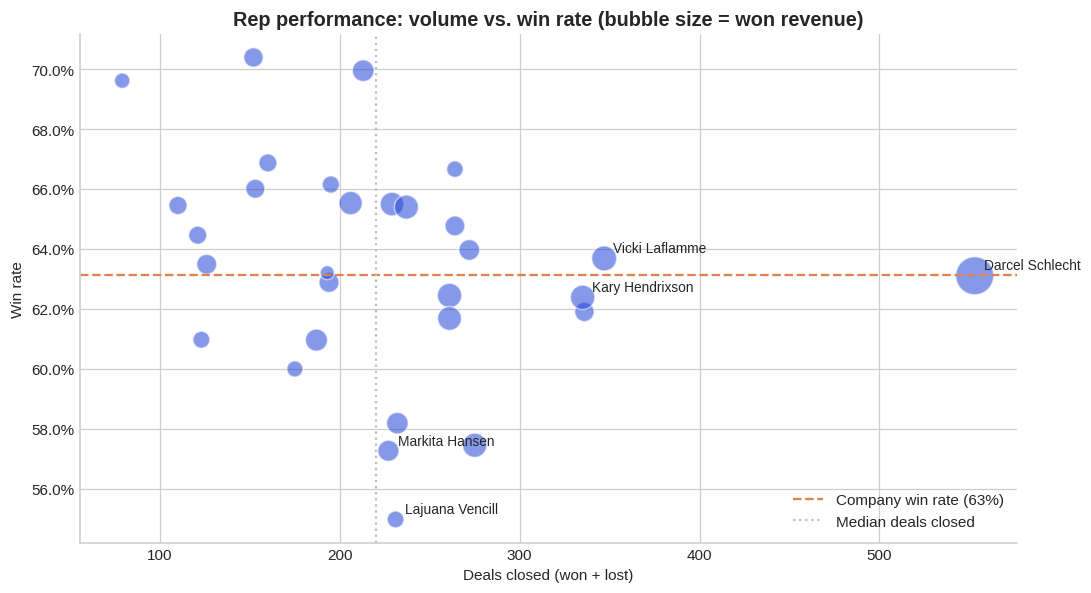

In [12]:
reps = (df.groupby(["sales_agent", "manager", "regional_office"])
          .agg(closed=("is_closed", "sum"), won=("is_won", "sum"),
               won_revenue=("close_value", "sum"), open_deals=("is_closed", lambda s: (~s).sum()))
          .reset_index()
          .assign(win_rate=lambda t: t["won"] / t["closed"]))

avg_wr = kpi["Win rate (won / closed)"]
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(reps["closed"], reps["win_rate"], s=reps["won_revenue"] / reps["won_revenue"].max() * 600 + 20,
                c=ACCENT, alpha=.55, edgecolor="white")
ax.axhline(avg_wr, color="#DD8452", ls="--", label=f"Company win rate ({avg_wr:.0%})")
ax.axvline(reps["closed"].median(), color=GREY, ls=":", label="Median deals closed")
for _, r in pd.concat([reps.nlargest(3, "won_revenue"), reps.nsmallest(2, "win_rate")]).iterrows():
    ax.annotate(r["sales_agent"], (r["closed"], r["win_rate"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_xlabel("Deals closed (won + lost)"); ax.set_ylabel("Win rate")
ax.set_title("Rep performance: volume vs. win rate (bubble size = won revenue)")
ax.legend(loc="lower right")
save(fig, "05_rep_performance"); plt.show()

In [13]:
def team_table(level):
    t = (reps.groupby(level)
             .agg(reps=("sales_agent", "count"), won=("won", "sum"), closed=("closed", "sum"),
                  won_revenue=("won_revenue", "sum"), open_deals=("open_deals", "sum"))
             .assign(win_rate=lambda x: x["won"] / x["closed"],
                     revenue_per_rep=lambda x: x["won_revenue"] / x["reps"])
             .sort_values("revenue_per_rep", ascending=False))
    return t.style.format({"won_revenue": "${:,.0f}", "revenue_per_rep": "${:,.0f}", "win_rate": "{:.1%}"})

print("By regional office"); display(team_table("regional_office"))
print("By manager");         display(team_table("manager"))

By regional office


,reps,won,closed,won_revenue,open_deals,win_rate,revenue_per_rep
regional_office,,,,,,,
West,10,1438,2249,"$3,568,647",748,63.9%,"$356,865"
Central,10,1629,2604,"$3,346,293",908,62.6%,"$334,629"
East,10,1171,1858,"$3,090,594",433,63.0%,"$309,059"


By manager


,reps,won,closed,won_revenue,open_deals,win_rate,revenue_per_rep
manager,,,,,,,
Melvin Marxen,5,882,1418,"$2,251,930",511,62.2%,"$450,386"
Summer Sewald,5,828,1287,"$1,964,750",414,64.3%,"$392,950"
Rocco Neubert,5,691,1113,"$1,960,545",214,62.1%,"$392,109"
Celia Rouche,5,610,962,"$1,603,897",334,63.4%,"$320,779"
Cara Losch,5,480,745,"$1,130,049",219,64.4%,"$226,010"
Dustin Brinkmann,5,747,1186,"$1,094,363",397,63.0%,"$218,873"


## 10. Sector view: who buys?

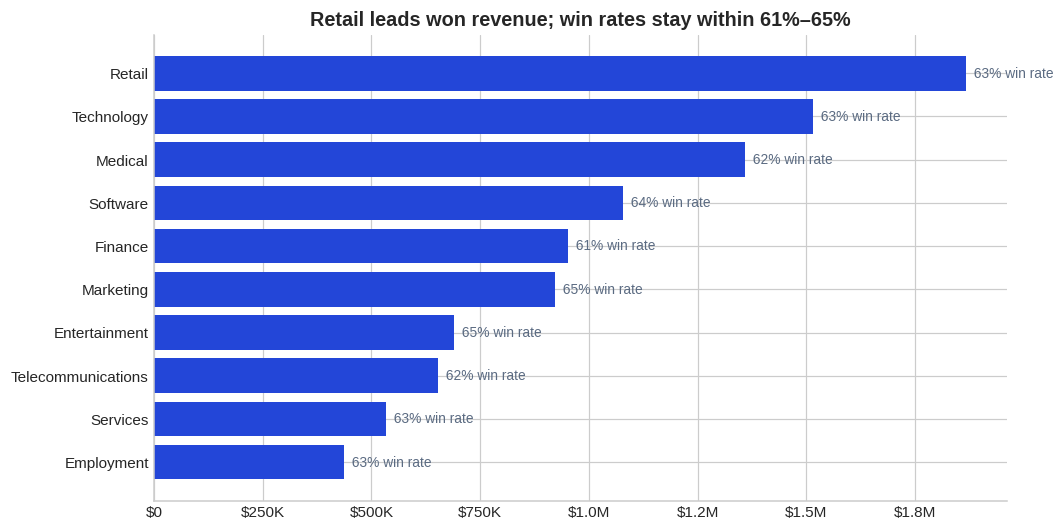

In [14]:
sec = (closed.dropna(subset=["sector"]).groupby("sector")
             .agg(closed=("is_won", "size"), won=("is_won", "sum"), won_revenue=("close_value", "sum"))
             .assign(win_rate=lambda t: t["won"] / t["closed"])
             .sort_values("won_revenue"))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(sec.index.str.title(), sec["won_revenue"], color=ACCENT)
for i, (rev, wr) in enumerate(zip(sec["won_revenue"], sec["win_rate"])):
    ax.text(rev, i, f"  {wr:.0%} win rate", va="center", fontsize=9, color="#5B6B82")
ax.xaxis.set_major_formatter(usd)
ax.set_title(f"{sec.index[-1].title()} leads won revenue; win rates stay within "
             f"{sec['win_rate'].min():.0%}–{sec['win_rate'].max():.0%}")
save(fig, "06_sectors"); plt.show()

## 11. Key numbers for the recommendations

In [15]:
top_rev = prod["won_revenue"].idxmax()
best_wr, worst_wr = prod["win_rate"].idxmax(), prod["win_rate"].idxmin()
low_price = prod["avg_price_realization"].idxmin()
top_rep = reps.loc[reps["won_revenue"].idxmax()]
low_reps = reps[(reps["win_rate"] < avg_wr - 0.05) & (reps["closed"] >= reps["closed"].median())]
stale = df[(df["deal_stage"] == "Engaging") & (df["engage_date"] < df["engage_date"].max() - pd.Timedelta(days=90))]

print(f"• Won revenue: ${kpi['Won revenue']:,.0f} | Win rate: {avg_wr:.1%} | Median cycle: {kpi['Median sales cycle (days)']:.0f} days")
print(f"• Top product by revenue: {top_rev} ({prod.loc[top_rev, 'won_revenue'] / prod['won_revenue'].sum():.0%} of won revenue)")
print(f"• Highest win rate: {best_wr} ({prod.loc[best_wr, 'win_rate']:.1%}) | Lowest: {worst_wr} ({prod.loc[worst_wr, 'win_rate']:.1%})")
print(f"• Lowest price realization: {low_price} ({prod.loc[low_price, 'avg_price_realization']:.1%} of list price)")
print(f"• Top rep: {top_rep['sales_agent']} (${top_rep['won_revenue']:,.0f}, {top_rep['win_rate']:.0%} win rate)")
print(f"• High-volume reps >5 p.p. below average win rate: {len(low_reps)}")
print(f"• Engaging deals older than 90 days (stale pipeline): {len(stale):,} "
      f"({len(stale) / (df['deal_stage'] == 'Engaging').sum():.0%} of Engaging)")

• Won revenue: $10,005,534 | Win rate: 63.2% | Median cycle: 45 days
• Top product by revenue: GTX Pro (35% of won revenue)
• Highest win rate: MG Special (64.8%) | Lowest: GTK 500 (60.0%)
• Lowest price realization: GTX Plus Basic (98.5% of list price)
• Top rep: Darcel Schlecht ($1,153,214, 63% win rate)
• High-volume reps >5 p.p. below average win rate: 3
• Engaging deals older than 90 days (stale pipeline): 1,465 (92% of Engaging)


## 12. Insights and recommendations

*For the VP of Sales · Data: Oct 2016 – Dec 2017*

**Summary.** The team closed **$10.0M** in won revenue at a **63.2% win rate**, with a median sales cycle of **45 days**. Pricing and product win rates are healthy. The main risks are an unreliable open pipeline and revenue concentrated in one product and a few people.

**1. The open pipeline is not reliable.** 1,465 deals — **92% of all Engaging deals** — have been open for more than 90 days, twice the 45-day median cycle. The forecast built on these deals is likely overstated.
**Recommendation:** flag Engaging deals automatically after 90 days, review them weekly (advance with a dated next step or close as lost), and report the forecast with and without stale deals.

**2. Win rate is not a product problem.** Win rates range only from 60.0% (GTK 500) to 64.8% (MG Special), a 4.8 p.p. spread. Meanwhile, GTX Pro alone brings 35% of won revenue.
**Recommendation:** focus enablement on sales process and qualification rather than product training, and set pipeline targets for second-tier products to reduce dependence on GTX Pro.

**3. Pricing discipline is strong.** Even the product with the lowest price realization (GTX Plus Basic) closes at 98.5% of list price.
**Recommendation:** no new discount approvals are needed — they would only add friction. Keep price realization as a monitored KPI.

**4. Performance gaps are about execution and concentration.** Three high-volume reps win more than 5 p.p. below the company average. The top rep, Darcel Schlecht, generated $1.15M (11.5% of all won revenue) at a 63% win rate — right at the average, so the result comes from volume and deal selection, not a higher close rate.
**Recommendation:** run lost-deal reviews with the three reps, document the top rep's prospecting and deal-selection habits as a playbook, and treat the revenue concentration as a retention risk.

**5. CRM data quality needs guardrails.** Product names (`GTXPro` vs `GTX Pro`) and sector labels (`technolgy`) were inconsistent across tables, which silently breaks joins and reports.
**Recommendation:** replace free-text fields with picklists and add validation rules.